# Synthetic OEE Time-Series Dataset Generation

20,000-row dataset for ANN OEE Horizon Prediction Engine

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [13]:
seed_df = pd.read_csv(
    "data/lathe_job_status_data.csv",
    sep=";"
)

print("=== Seed Data ===")
print("Columns:", seed_df.columns.tolist())
print()
print(seed_df.head())
print()
print(f"Shape: {seed_df.shape}")
print()
print("Note: CSV column is 'Avaliability' (typo) -> using 'Availability' in generated data")

=== Seed Data ===
Columns: ['Current_Job_SLNo', 'Batch_PartNo', 'Part_SLNo', 'Component', 'Production_Started', 'Production_Completed', 'Avaliability', 'Performance', 'Quality', 'OEE', 'Planned_Sales', 'Income', 'Loss', 'Customer_ID', 'Project', 'Supervisor_ID']

   Current_Job_SLNo Batch_PartNo  Part_SLNo            Component  \
0                 1    RA-21-A-X          3  25/08/2025 12:19:00   
1                 2    RA-21-A-X          3  25/08/2025 19:53:00   
2                 3    RA-21-A-X          3  25/08/2025 20:06:00   
3                 4    RA-21-A-X          3  25/08/2025 20:32:00   
4                 5    RA-21-A-X          3  27/08/2025 14:45:00   

    Production_Started Production_Completed  Avaliability  Performance  \
0  25/08/2025 12:22:01           Base plate           100           99   
1  25/08/2025 19:56:30           Base plate            98           86   
2  25/08/2025 20:10:07           Base plate           100           73   
3  25/08/2025 20:35:59         

In [14]:
np.random.seed(42)

n_rows = 20000
start_time = datetime(2026, 1, 1, 0, 0, 0)
timestamps = [start_time + timedelta(minutes=i) for i in range(n_rows)]

PHI = 0.998

rpm = np.zeros(n_rows)
availability = np.ones(n_rows) * 88.0
performance = np.ones(n_rows) * 82.0
quality = np.ones(n_rows) * 86.0

for i in range(1, n_rows):
    rpm[i] = np.clip(rpm[i-1] + np.random.uniform(-3, 3), 300, 500)
    availability[i] = (1-PHI)*88.0 + PHI*availability[i-1] + np.random.normal(0, 0.3)
    performance[i] = (1-PHI)*(82.0 + (rpm[i]-400)*0.02) + PHI*performance[i-1] + np.random.normal(0, 0.3)
    quality[i] = (1-PHI)*86.0 + PHI*quality[i-1] + np.random.normal(0, 0.25)

availability = np.clip(availability, 40, 100)
performance = np.clip(performance, 30, 100)
quality = np.clip(quality, 40, 100)
oee = np.clip((availability * performance * quality) / 10000.0, 10, 100)

# Place downtime events at positions where OEE at t+60 is lowest
target_vals = oee[60:]
n_events = 1200
event_positions = np.argsort(target_vals)[:n_events]

downtime_minutes = np.zeros(n_rows)
for idx in event_positions:
    dt_val = min(np.random.exponential(scale=14), 40)
    downtime_minutes[idx] = round(dt_val, 1)

df = pd.DataFrame({
    'timestamp': timestamps,
    'rpm': rpm.round(1),
    'availability': availability.round(2),
    'performance': performance.round(2),
    'quality': quality.round(2),
    'current_oee': oee.round(2),
    'downtime_minutes': downtime_minutes,
})

print(f"Generated {len(df)} rows")

print("\n=== Correlation: current state vs target_oee_1h ===")
temp = df.copy()
temp['target_oee_1h'] = temp['current_oee'].shift(-60)
temp = temp.dropna()
for col in ['current_oee', 'rpm', 'availability', 'performance', 'quality', 'downtime_minutes']:
    c = temp[col].corr(temp['target_oee_1h'])
    print(f"  {col:20s} → target_oee_1h: {c:.3f}")

print("\n=== State correlations ===")
corr_cols = ['rpm', 'availability', 'performance', 'quality', 'current_oee', 'downtime_minutes']
print(df[corr_cols].corr().round(3))

print("\n=== Distributions ===")
for col in ['availability', 'performance', 'quality', 'current_oee']:
    print(f"  {col:15s} min={df[col].min():6.1f}  max={df[col].max():6.1f}  mean={df[col].mean():6.1f}  std={df[col].std():6.1f}")

print(f"\n  Downtime events: {(df['downtime_minutes']>0).sum()}/{len(df)} = {(df['downtime_minutes']>0).mean()*100:.1f}%")
print(f"  Mean OEE when downtime>0: {df[df['downtime_minutes']>0]['current_oee'].mean():.1f}")
print(f"  Mean OEE when downtime=0: {df[df['downtime_minutes']==0]['current_oee'].mean():.1f}")


Generated 20000 rows

=== Correlation: current state vs target_oee_1h ===
  current_oee          → target_oee_1h: 0.888
  rpm                  → target_oee_1h: 0.309
  availability         → target_oee_1h: 0.620
  performance          → target_oee_1h: 0.525
  quality              → target_oee_1h: 0.602
  downtime_minutes     → target_oee_1h: -0.349

=== State correlations ===
                    rpm  availability  performance  quality  current_oee  \
rpm               1.000         0.159        0.212    0.240        0.309   
availability      0.159         1.000        0.163    0.232        0.704   
performance       0.212         0.163        1.000    0.052        0.621   
quality           0.240         0.232        0.052    1.000        0.647   
current_oee       0.309         0.704        0.621    0.647        1.000   
downtime_minutes -0.137        -0.302       -0.079   -0.218       -0.292   

                  downtime_minutes  
rpm                         -0.137  
availability  

In [15]:
df['target_oee_30m'] = df['current_oee'].shift(-30)
df['target_oee_1h'] = df['current_oee'].shift(-60)
df['target_oee_2h'] = df['current_oee'].shift(-120)
df['target_oee_6h'] = df['current_oee'].shift(-360)
df['target_oee_8h'] = df['current_oee'].shift(-480)

before = len(df)
df = df.dropna().reset_index(drop=True)
after = len(df)
print(f"Rows before dropna: {before}")
print(f"Rows after dropna: {after}")
print(f"Rows removed: {before - after}")


Rows before dropna: 20000
Rows after dropna: 19520
Rows removed: 480


In [16]:
df.to_csv("data/syn_timeseries_oee.csv", index=False)
print(f"Saved: {df.shape}")

Saved: (19520, 12)


In [17]:
print("=== DataFrame Info ===")
print()
df.info()
print()
print("=== Null Check ===")
print(df.isnull().sum())
print()
print("=== Descriptive Statistics ===")
df.describe()

=== DataFrame Info ===

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19520 entries, 0 to 19519
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   timestamp         19520 non-null  datetime64[ns]
 1   rpm               19520 non-null  float64       
 2   availability      19520 non-null  float64       
 3   performance       19520 non-null  float64       
 4   quality           19520 non-null  float64       
 5   current_oee       19520 non-null  float64       
 6   downtime_minutes  19520 non-null  float64       
 7   target_oee_30m    19520 non-null  float64       
 8   target_oee_1h     19520 non-null  float64       
 9   target_oee_2h     19520 non-null  float64       
 10  target_oee_6h     19520 non-null  float64       
 11  target_oee_8h     19520 non-null  float64       
dtypes: datetime64[ns](1), float64(11)
memory usage: 1.8 MB

=== Null Check ===
timestamp           0
rpm      

,timestamp,rpm,availability,performance,quality,current_oee,downtime_minutes,target_oee_30m,target_oee_1h,target_oee_2h,target_oee_6h,target_oee_8h
count,19520,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000,19520.000000
mean,2026-01-07 18:39:30,394.398330,87.902133,83.245233,85.545722,62.655906,0.806219,62.651251,62.646157,62.624608,62.494114,62.420226
min,2026-01-01 00:00:00,0.000000,74.400000,73.910000,75.610000,47.930000,0.000000,47.930000,47.930000,47.930000,47.930000,47.930000
25%,2026-01-04 09:19:45,350.600000,85.470000,80.280000,83.050000,58.800000,0.000000,58.770000,58.770000,58.770000,58.550000,58.460000
50%,2026-01-07 18:39:30,395.800000,88.120000,83.070000,85.590000,62.740000,0.000000,62.740000,62.730000,62.700000,62.510000,62.410000
75%,2026-01-11 03:59:15,437.100000,90.490000,86.060000,87.880000,66.160000,0.000000,66.160000,66.160000,66.130000,66.030000,65.950000
max,2026-01-14 13:19:00,500.000000,100.000000,93.540000,97.420000,83.200000,40.000000,83.200000,83.200000,83.200000,83.200000,83.200000
std,NaN,54.127926,4.052591,3.828393,3.871437,5.676578,4.292142,5.679578,5.680209,5.674892,5.697243,5.715649


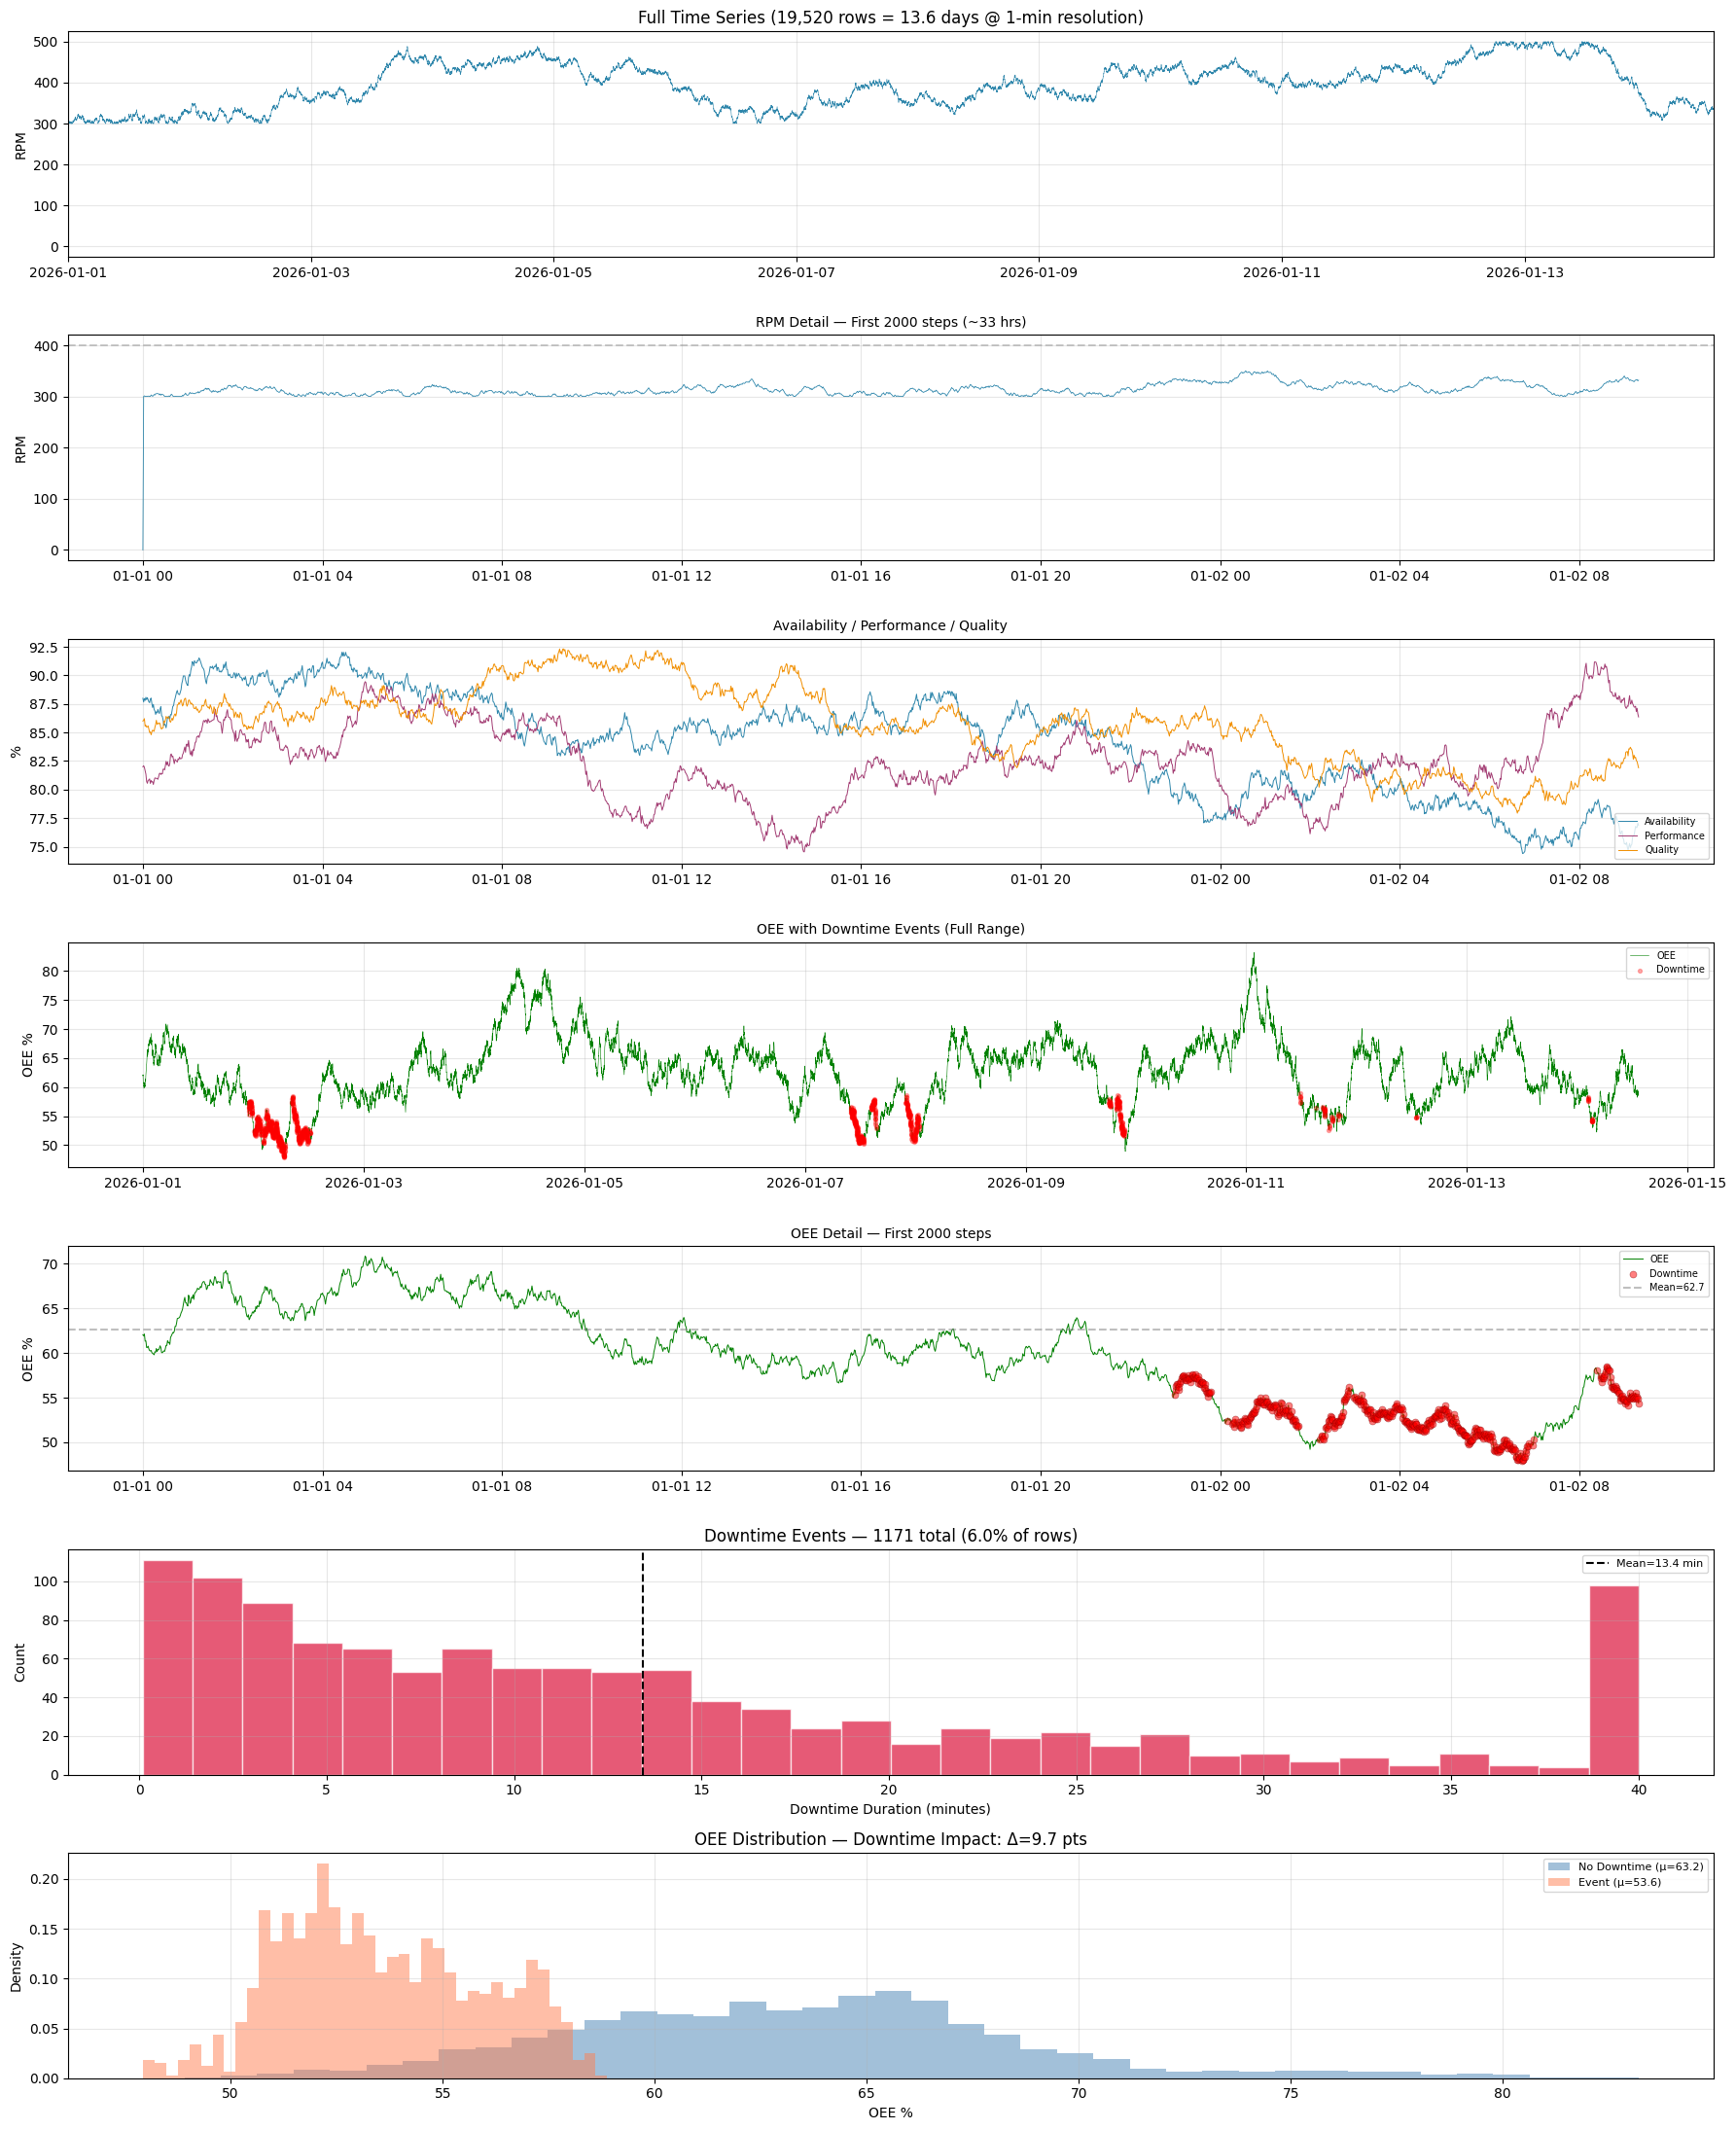

In [18]:
fig = plt.figure(figsize=(18, 22))

# 1. FULL TIME SERIES — RPM
ax1 = plt.subplot(7, 1, 1)
ax1.plot(df['timestamp'], df['rpm'], color='#2E86AB', linewidth=0.4)
ax1.set_ylabel('RPM')
ax1.set_title('Full Time Series (19,520 rows = 13.6 days @ 1-min resolution)', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([df['timestamp'].iloc[0], df['timestamp'].iloc[-1]])

# 2. FIRST 2000 — RPM zoom
ax2 = plt.subplot(7, 1, 2)
n = 2000
ax2.plot(df['timestamp'].iloc[:n], df['rpm'].iloc[:n], color='#2E86AB', linewidth=0.6)
ax2.axhline(y=400, color='gray', ls='--', alpha=0.4)
ax2.set_ylabel('RPM')
ax2.set_title(f'RPM Detail — First {n} steps (~33 hrs)', fontsize=10)
ax2.grid(True, alpha=0.3)

# 3. A/P/Q overlay — first 2000
ax3 = plt.subplot(7, 1, 3)
ax3.plot(df['timestamp'].iloc[:n], df['availability'].iloc[:n], label='Availability', linewidth=0.7, color='#2E86AB')
ax3.plot(df['timestamp'].iloc[:n], df['performance'].iloc[:n], label='Performance', linewidth=0.7, color='#A23B72')
ax3.plot(df['timestamp'].iloc[:n], df['quality'].iloc[:n], label='Quality', linewidth=0.7, color='#F18F01')
ax3.set_ylabel('%')
ax3.set_title('Availability / Performance / Quality', fontsize=10)
ax3.legend(fontsize=7, loc='lower right')
ax3.grid(True, alpha=0.3)

# 4. OEE + Downtime — Full range
ax4 = plt.subplot(7, 1, 4)
ax4.plot(df['timestamp'], df['current_oee'], color='green', linewidth=0.4, label='OEE')
dt_scatter = df[df['downtime_minutes'] > 0]
ax4.scatter(dt_scatter['timestamp'], dt_scatter['current_oee'],
            c='red', s=8, alpha=0.3, label='Downtime', zorder=3)
ax4.set_ylabel('OEE %')
ax4.set_title('OEE with Downtime Events (Full Range)', fontsize=10)
ax4.legend(fontsize=7)
ax4.grid(True, alpha=0.3)

# 5. OEE zoom — first 2000
ax5 = plt.subplot(7, 1, 5)
ax5.plot(df['timestamp'].iloc[:n], df['current_oee'].iloc[:n], color='green', linewidth=0.7, label='OEE')
dt_zoom = dt_scatter[dt_scatter.index < n]
ax5.scatter(dt_zoom['timestamp'], dt_zoom['current_oee'],
            c='red', s=25, alpha=0.5, label='Downtime', zorder=3, edgecolors='darkred', linewidth=0.5)
ax5.axhline(y=df['current_oee'].mean(), color='gray', ls='--', alpha=0.5, label=f'Mean={df.current_oee.mean():.1f}')
ax5.set_ylabel('OEE %')
ax5.set_title(f'OEE Detail — First {n} steps', fontsize=10)
ax5.legend(fontsize=7)
ax5.grid(True, alpha=0.3)

# 6. Downtime event distribution
ax6 = plt.subplot(7, 1, 6)
dt_vals = df[df['downtime_minutes'] > 0]['downtime_minutes']
ax6.hist(dt_vals, bins=30, color='crimson', edgecolor='white', alpha=0.7)
ax6.axvline(dt_vals.mean(), color='black', ls='--', lw=1.5, label=f'Mean={dt_vals.mean():.1f} min')
ax6.set_xlabel('Downtime Duration (minutes)')
ax6.set_ylabel('Count')
ax6.set_title(f'Downtime Events — {len(dt_vals)} total ({len(dt_vals)/len(df)*100:.1f}% of rows)')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# 7. OEE distribution comparison: with vs without downtime
ax7 = plt.subplot(7, 1, 7)
dt_yes = df[df['downtime_minutes'] > 0]['current_oee']
dt_no = df[df['downtime_minutes'] == 0]['current_oee']
ax7.hist(dt_no, bins=40, alpha=0.5, color='steelblue', label=f'No Downtime (μ={dt_no.mean():.1f})', density=True)
ax7.hist(dt_yes, bins=40, alpha=0.5, color='coral', label=f'Event (μ={dt_yes.mean():.1f})', density=True)
ax7.set_xlabel('OEE %')
ax7.set_ylabel('Density')
ax7.set_title(f'OEE Distribution — Downtime Impact: Δ={dt_no.mean()-dt_yes.mean():.1f} pts')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


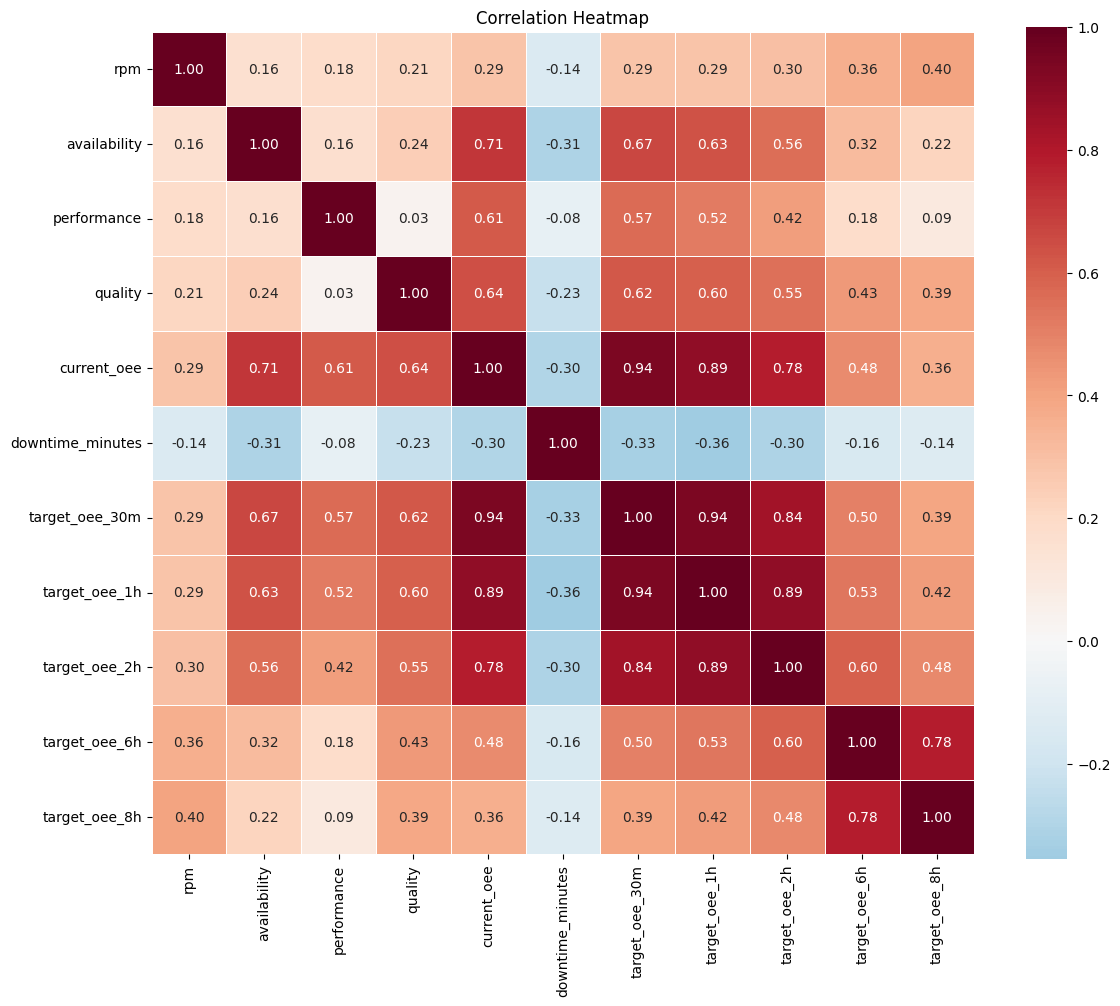

In [47]:
plt.figure(figsize=(12, 10))

numeric_cols = [
    'rpm', 'availability', 'performance', 'quality',
    'current_oee', 'downtime_minutes',
    'target_oee_30m', 'target_oee_1h',
    'target_oee_2h', 'target_oee_6h', 'target_oee_8h'
]

corr = df[numeric_cols].corr()

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()


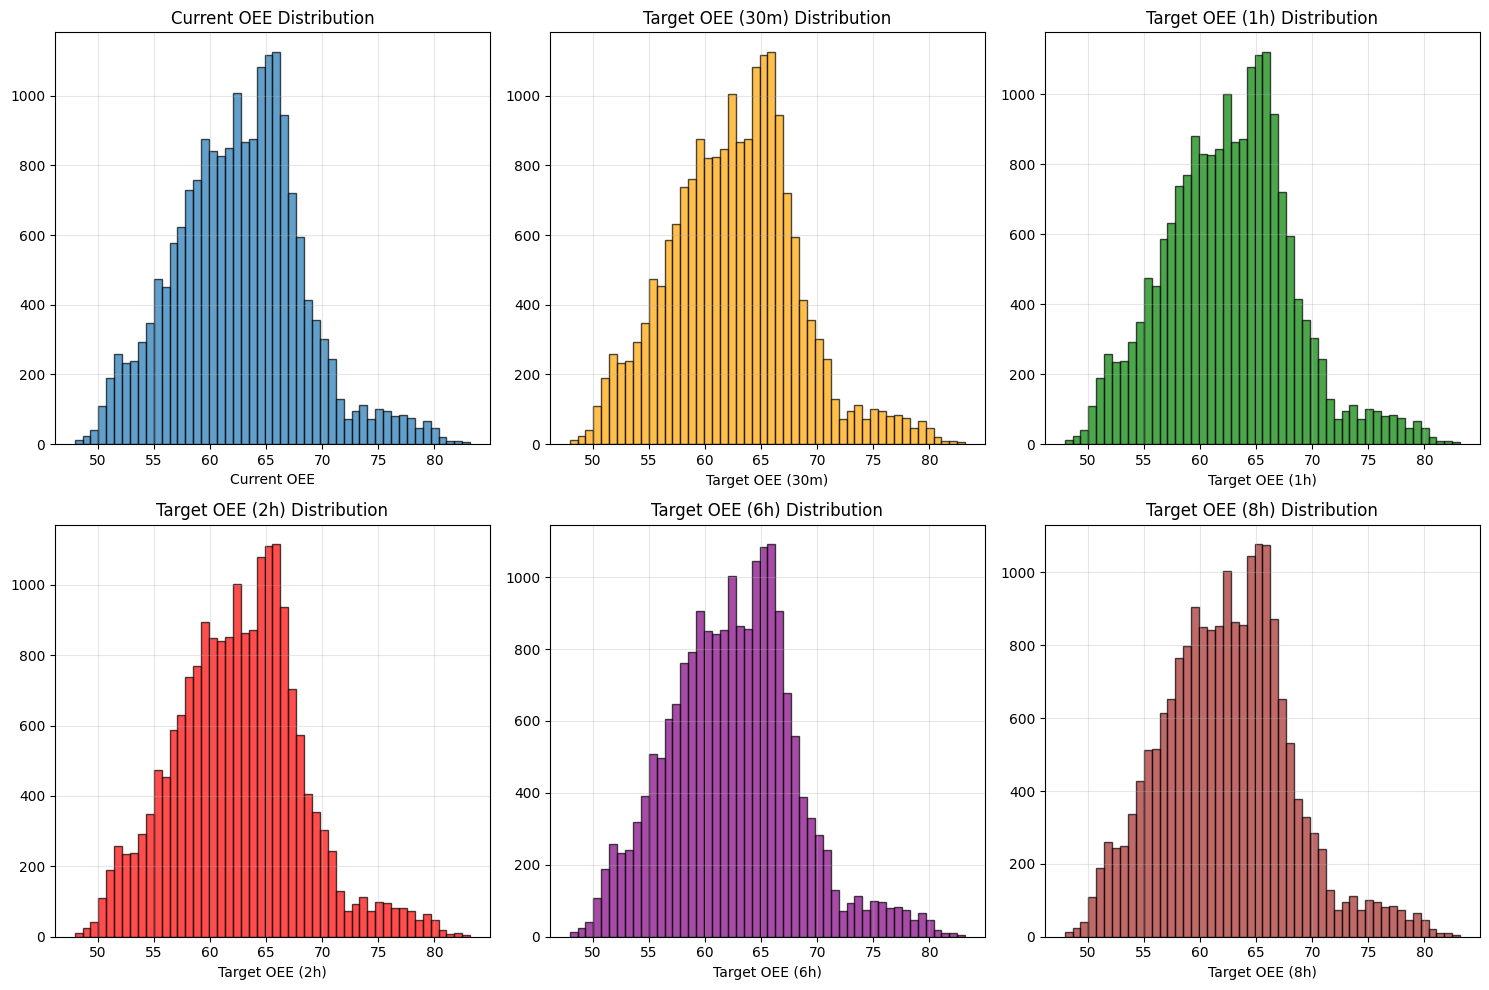

In [48]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].hist(df['current_oee'], bins=50, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Current OEE')
axes[0, 0].set_title('Current OEE Distribution')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(df['target_oee_30m'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0, 1].set_xlabel('Target OEE (30m)')
axes[0, 1].set_title('Target OEE (30m) Distribution')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(df['target_oee_1h'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0, 2].set_xlabel('Target OEE (1h)')
axes[0, 2].set_title('Target OEE (1h) Distribution')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].hist(df['target_oee_2h'], bins=50, edgecolor='black', alpha=0.7, color='red')
axes[1, 0].set_xlabel('Target OEE (2h)')
axes[1, 0].set_title('Target OEE (2h) Distribution')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(df['target_oee_6h'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1, 1].set_xlabel('Target OEE (6h)')
axes[1, 1].set_title('Target OEE (6h) Distribution')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(df['target_oee_8h'], bins=50, edgecolor='black', alpha=0.7, color='brown')
axes[1, 2].set_xlabel('Target OEE (8h)')
axes[1, 2].set_title('Target OEE (8h) Distribution')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


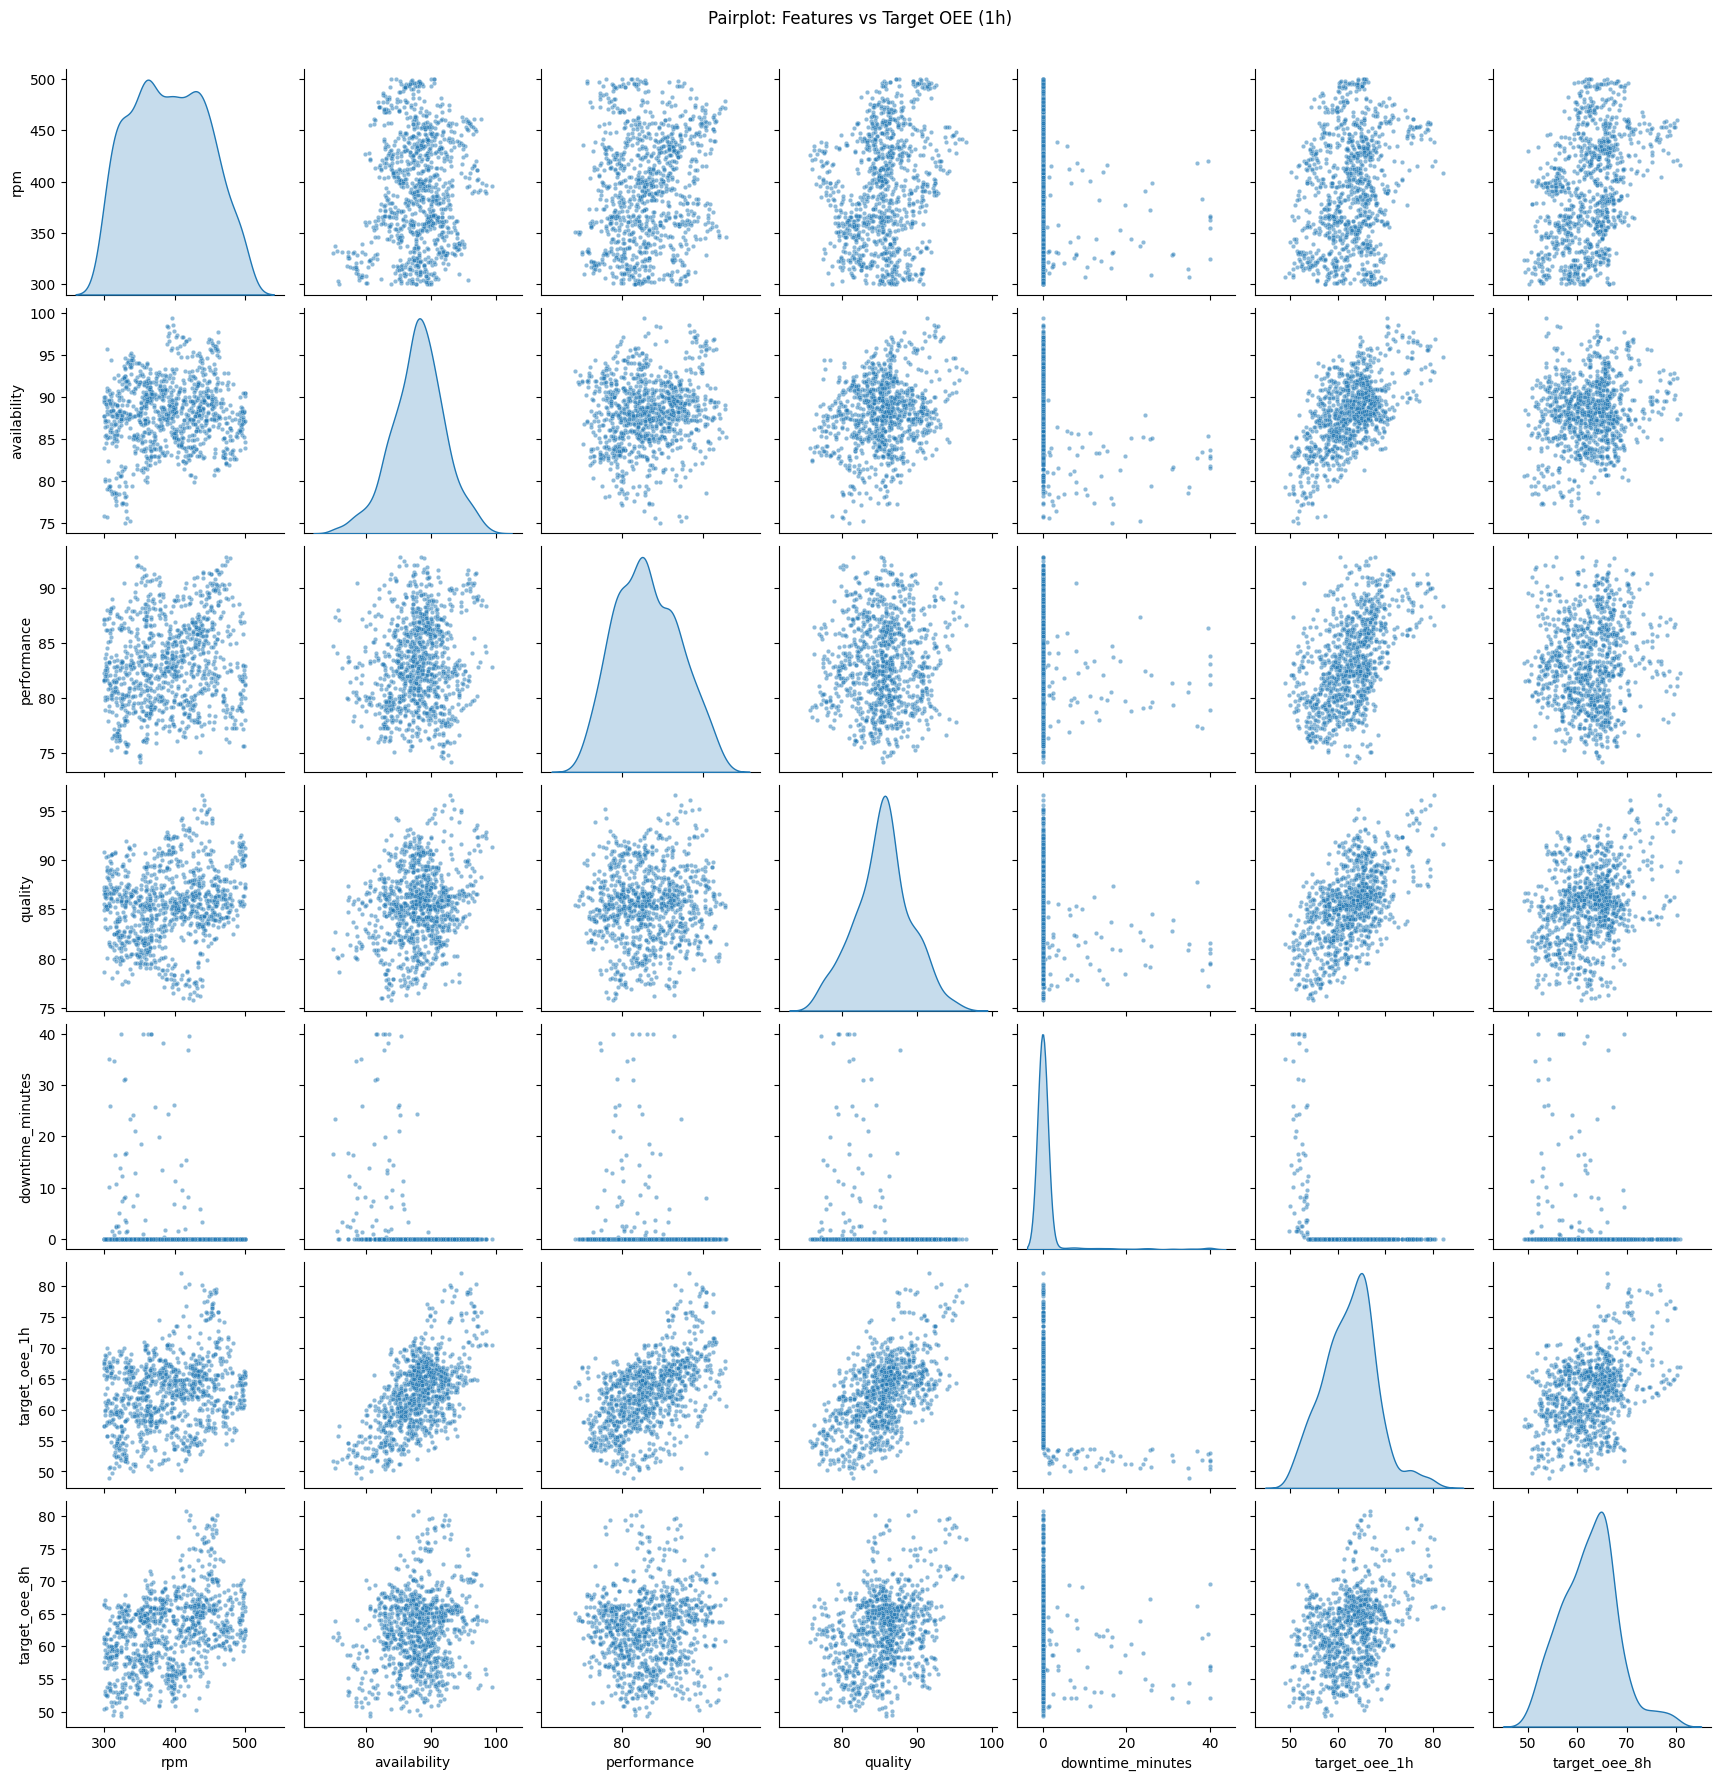

In [49]:
sample_df = df[
    ['rpm', 'availability', 'performance', 'quality',
     'downtime_minutes', 'target_oee_1h', 'target_oee_8h']
].sample(1000, random_state=42)

sns.pairplot(sample_df, diag_kind='kde', plot_kws={'alpha': 0.5, 's': 10})
plt.suptitle('Pairplot: Features vs Target OEE (1h)', y=1.02)
plt.show()
